In [148]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os

In [149]:
import json
from pprint import pprint

path = r'jobs\20251019_184217\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h256-128'

metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


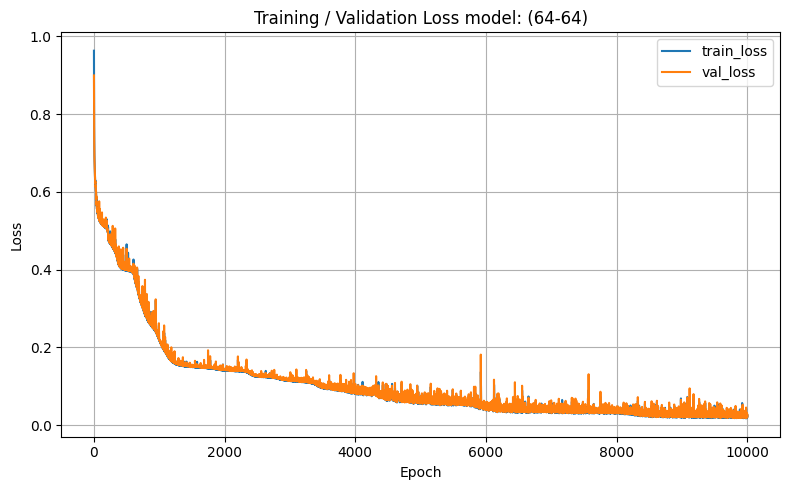

In [150]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss model: (64-64)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [151]:
import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [152]:
metrics_data['y_norm']

{'mean': -2.0867715541661447e-11, 'std': 1.9999989220309544e-08}

In [153]:
metrics_data.keys()

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])

In [154]:
metrics_data['args']

{'datapath': 'data/dataset100K25M.pkl',
 'model_type': 'fc1',
 'norm': 'minmax',
 'epochs': 10000,
 'batch_size': 2048,
 'lr': 0.001,
 'val_split': 0.2,
 'seed': 42,
 'fc1_hidden': [256, 128],
 'fc1_activation': 'leaky_relu',
 'fc1_final_activation': 'leaky_relu',
 'fc1_dropout': 0.0,
 'cnn1_img_out': 32,
 'cnn1_dm_hidden': 32,
 'resume': None,
 'freeze': False,
 'out_dir': '/scratch/network/ak9088/NASA-RL-Wavefront-Control/RL/jobs/20251019_184217/exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h256-128'}

In [155]:
metrics_data['input_shape']

[20, 20, 3]

In [156]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=256, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=128, out_features=25, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
  )
)

In [157]:
from environment import CoronagraphEnvironment

env_config = metrics_data['dataset_meta']['environment_config']
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')

env = CoronagraphEnvironment(**env_config)

initializing coronagraph env. might take a minute.


In [158]:
import pickle
from pathlib import Path

dataset_path = Path(r'data\dataset100S25M.pkl')
if not dataset_path.exists():
    raise FileNotFoundError(f"{dataset_path} not found")

with dataset_path.open('rb') as f:
    dataset = pickle.load(f)

print("Loaded:", dataset_path)
print("Type:", type(dataset))

if isinstance(dataset, dict):
    print("Keys:", list(dataset.keys()))
elif isinstance(dataset, (list, tuple)):
    print("Length:", len(dataset))
else:
    try:
        arr = np.asarray(dataset)  # np imported in another cell
        print("As numpy array shape:", arr.shape)
    except Exception:
        pass

# show a small preview without dumping everything
if isinstance(dataset, dict):
    for k in list(dataset.keys())[:10]:
        v = dataset[k]
        if isinstance(v, (list, tuple)):
            print(f"{k}: list len={len(v)}")
        else:
            print(f"{k}: type={type(v)}")
elif isinstance(dataset, (list, tuple)) and len(dataset):
    print("First element type:", type(dataset[0]))
    try:
        preview = dataset[0]
        if isinstance(preview, (list, tuple, dict, np.ndarray)):
            print("Preview (first element):", (preview if isinstance(preview, dict) else (np.asarray(preview).shape if hasattr(preview, '__len__') else type(preview))))
        else:
            print("Preview (first element):", preview)
    except Exception:
        pass

Loaded: data\dataset100S25M.pkl
Type: <class 'dict'>
Keys: ['dm_settings', 'images', 'meta']
dm_settings: list len=100
images: list len=100
meta: type=<class 'dict'>


In [172]:
new_imgs, _ = NORMALIZERS['minmax'](np.array(dataset['images']), **params)
print(new_imgs.shape)

(100, 3, 20, 20)


In [ ]:
print()

[array([ 2.47088691e-08, -2.42098717e-08,  2.48815320e-08,  4.75422193e-08,
        1.08647388e-08,  4.64441145e-09, -8.69068416e-10, -3.99172709e-08,
        4.38548554e-09, -3.20682418e-09,  2.47284589e-08, -2.86380899e-08,
       -9.33388712e-09,  1.02257231e-08,  1.00917321e-08, -2.78511378e-08,
        8.71896409e-09,  1.87256905e-08, -2.33765682e-09, -7.87744009e-09,
        2.27863288e-09,  1.54440085e-08, -1.74634188e-08, -8.27456296e-09,
        2.34208325e-08]), array([ 1.99760360e-08,  4.83099372e-08,  3.03950830e-08,  4.12252029e-08,
       -1.73165716e-08,  1.37000493e-08,  1.03958750e-09, -3.37764269e-09,
       -1.20563734e-08,  1.77355286e-08, -2.36280071e-08, -2.98795106e-09,
        2.93287455e-08,  2.29598722e-08,  1.67591372e-08,  2.35082137e-08,
       -1.38630491e-08, -6.23092327e-10,  1.72434489e-08,  3.28762781e-09,
        8.81451690e-09,  3.63095607e-09,  5.71871753e-09,  1.64098078e-08,
       -1.46673993e-09]), array([ 3.60680133e-08, -1.74919079e-08, -1.241

imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 5.573382733648229
tensor([[ 2.6294e-10,  1.9366e-08, -1.3618e-09, -6.6840e-09, -4.6287e-09,
         -1.4609e-09, -3.7714e-10,  2.0405e-10,  2.9267e-09, -7.4624e-09,
         -7.0743e-09, -1.4255e-11, -1.0264e-09, -3.7374e-09, -3.2294e-09,
         -7.2720e-09, -2.0743e-10,  3.3081e-09, -3.8087e-10, -3.5265e-10,
         -2.3788e-09, -1.6892e-12, -2.1541e-10, -1.6300e-11, -9.9135e-11]])
[-9.60045719e-09 -4.91214180e-08  4.73360505e-09 -2.15788380e-09
 -8.09559645e-09  2.75906468e-09  2.17962568e-08 -1.81266523e-08
 -5.49507496e-08 -5.09835969e-09 -4.60291375e-09  1.16148966e-08
 -2.69402996e-10  1.60778420e-09 -1.73602330e-08  1.20083194e-08
  1.89846659e-08  3.51054717e-08 -1.67784202e-08  5.47833071e-09
 -2.21573316e-08 -5.00977461e-10  1.81353486e-08  1.46586103e-08
  1.35705316e-09]


C:\Users\alexe\AppData\Local\Temp\ipykernel_15880\3496915800.py:46: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_15880\3496915800.py:56: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


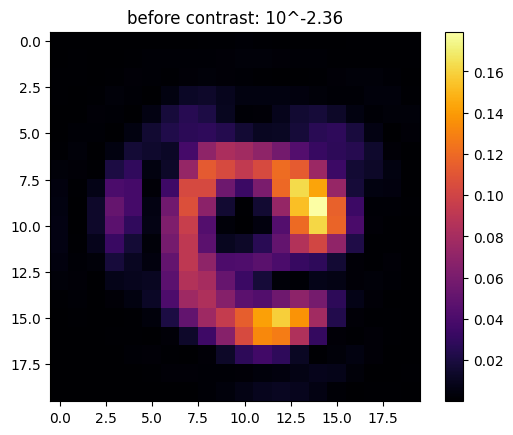

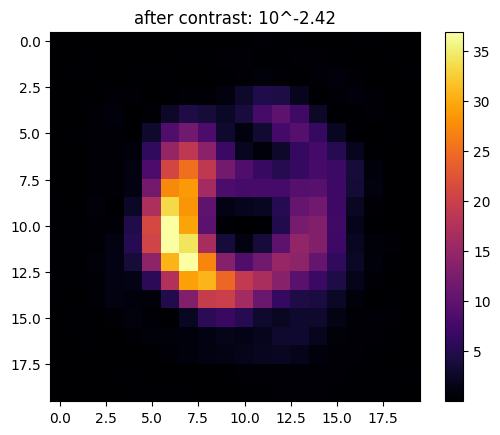

In [ ]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1
TEST_INDEX = 0

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        # env.deformable_mirror.flatten()
        # env.set_random_dm(noise=dm_random_noise)
        # original = env.deformable_mirror.actuators.copy()
        original = dataset['dm_settings'][TEST_INDEX]

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = new_imgs[TEST_INDEX][0]

        # img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = new_imgs[TEST_INDEX][1]

        # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = new_imgs[TEST_INDEX][2]
        # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs, dtype=torch.float).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()



[ 0.51821564  1.47204392 -1.27352795 -1.24340959 -0.14356663 -0.40846597
 -0.8559531   0.105969    0.1564877  -2.29366608 -1.59034893  0.20941097
 -0.41271489 -1.96462183 -0.79343036  1.04547593  0.21291627 -0.85867228
  0.88652022 -0.29723651  0.42853467  1.4468961  -0.35901629 -0.57741748
 -0.66533111]
imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 0.6671526595294807
tensor([[ 1.4197e-08,  3.1161e-08, -2.1069e-08, -2.5995e-08, -2.4007e-09,
         -6.5477e-09, -1.5173e-08,  2.1848e-09,  4.1409e-09, -4.5553e-08,
         -2.1394e-08,  5.2860e-09, -6.3956e-09, -3.9059e-08, -1.6560e-08,
          2.0153e-08,  4.0308e-09, -1.5754e-08,  1.7941e-08, -8.9808e-09,
          9.3615e-09,  2.7179e-08, -6.0055e-09, -9.9833e-09, -1.3200e-08]])
[ 1.03434396e-08  2.94199949e-08 -2.54914129e-08 -2.48890461e-08
 -2.89219878e-09 -8.19018272e-09 -1.71399206e-08  2.09851111e-09
  3.10888464e-09 -4.58941645e-08 -3.18278293e-08  4.16734947e-09
 -8.27516104e-09 -3.93132832e-08 -1.58894663e-08  2.088863

C:\Users\alexe\AppData\Local\Temp\ipykernel_15880\540448072.py:43: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_15880\540448072.py:53: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


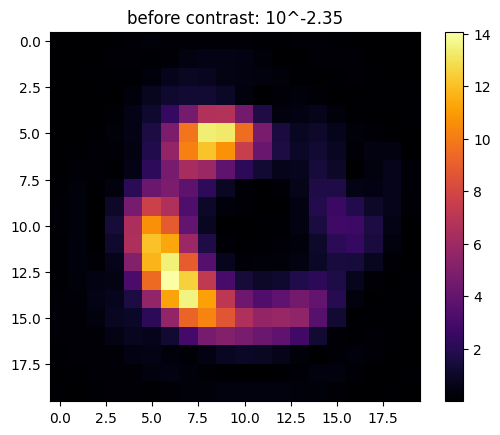

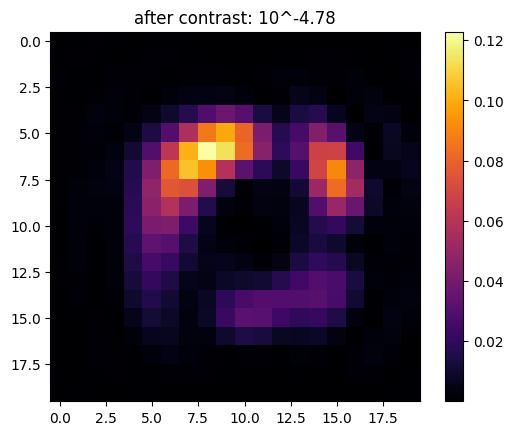

In [ ]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        env.deformable_mirror.flatten()
        env.set_random_dm(noise=dm_random_noise)
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)

        

        print((original - y_mean) / y_std)

        img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()

